In [32]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")


Libraries imported successfully!


In [33]:
# Load the dataset
# Dataset source: UCI Machine Learning Repository - Online Retail Dataset
# URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx
# Note: Download the dataset manually and place it in the project directory

import os

# Check if dataset exists
if not os.path.exists('Online_Retail.xlsx'):
    print("❌ Dataset not found!")
    print("📥 Please download the Online Retail dataset from:")
    print("🔗 https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx")
    print("📁 Save it as 'Online_Retail.xlsx' in the project directory")
    raise FileNotFoundError("Online_Retail.xlsx not found in current directory")

print("✅ Dataset found! Loading data...")

# Load data
df = pd.read_excel('Online_Retail.xlsx')
print(f"📊 Dataset shape: {df.shape}")
print(f"💾 Memory usage: {df.memory_usage().sum() / 1024**2:.1f} MB")
print("🎯 Ready for analysis!")


✅ Dataset found! Loading data...
📊 Dataset shape: (541909, 8)
💾 Memory usage: 33.1 MB
🎯 Ready for analysis!


In [34]:
# Initial data exploration
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)

print("\n=== FIRST 5 ROWS ===")
df.head()


=== DATASET OVERVIEW ===
Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

=== FIRST 5 ROWS ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [35]:
# Check for missing values and data quality
print("=== MISSING VALUES ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== DATA STATISTICS ===")
df.describe()


=== MISSING VALUES ===
             Missing Count  Missing Percentage
Description           1454            0.268311
CustomerID          135080           24.926694

=== DATA STATISTICS ===


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [36]:
# Data cleaning
print("=== BEFORE CLEANING ===")
print(f"Original shape: {df.shape}")

# Create a copy for cleaning
df_clean = df.copy()

# Remove rows with missing CustomerID (can't analyze customers without ID)
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f"After removing missing CustomerID: {df_clean.shape}")

# Remove negative quantities (returns) for this analysis
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"After removing negative quantities: {df_clean.shape}")

# Remove negative unit prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f"After removing negative prices: {df_clean.shape}")

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create additional features
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

print(f"\n=== AFTER CLEANING ===")
print(f"Final shape: {df_clean.shape}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Unique customers: {df_clean['CustomerID'].nunique()}")
print(f"Unique products: {df_clean['StockCode'].nunique()}")
print(f"Unique countries: {df_clean['Country'].nunique()}")


=== BEFORE CLEANING ===
Original shape: (541909, 8)
After removing missing CustomerID: (406829, 8)
After removing negative quantities: (397924, 8)
After removing negative prices: (397884, 8)

=== AFTER CLEANING ===
Final shape: (397884, 13)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4338
Unique products: 3665
Unique countries: 37


In [37]:
# Sales overview
total_revenue = df_clean['TotalAmount'].sum()
total_transactions = len(df_clean)
avg_order_value = df_clean.groupby('InvoiceNo')['TotalAmount'].sum().mean()
unique_customers = df_clean['CustomerID'].nunique()

print("=== BUSINESS METRICS ===")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Order Value: £{avg_order_value:.2f}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Revenue per Customer: £{total_revenue/unique_customers:.2f}")


=== BUSINESS METRICS ===
Total Revenue: £8,911,407.90
Total Transactions: 397,884
Average Order Value: £480.87
Unique Customers: 4,338
Revenue per Customer: £2054.27


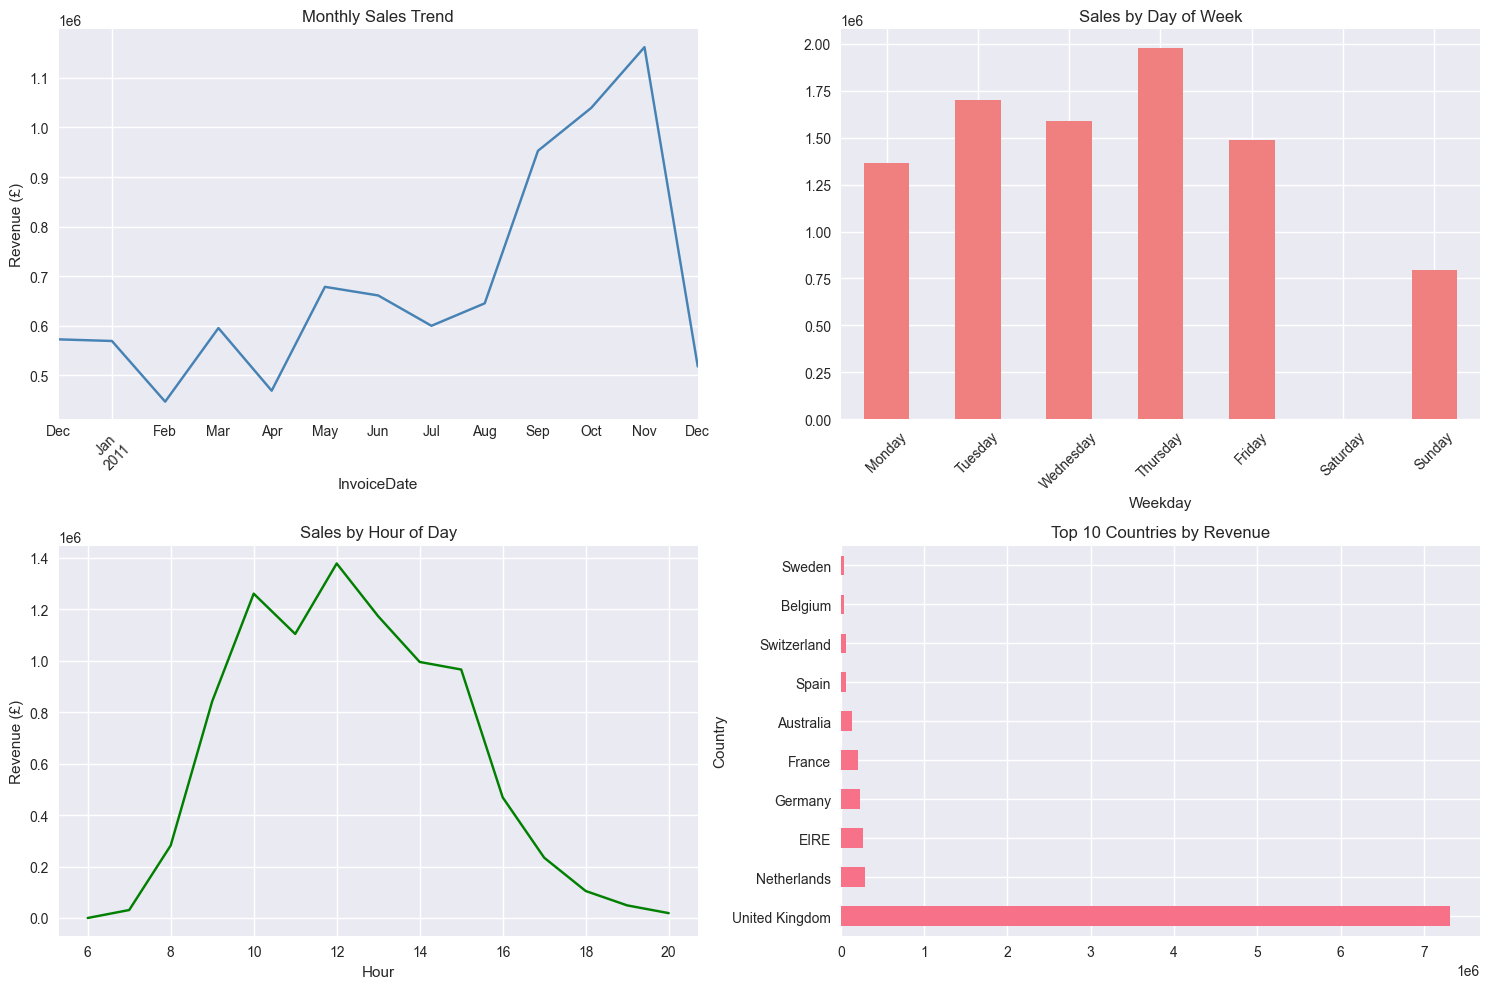

In [38]:
# Sales trends over time
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Monthly sales trend
monthly_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum()
monthly_sales.plot(kind='line', ax=axes[0,0], title='Monthly Sales Trend', color='steelblue')
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)

# Daily sales pattern
daily_sales = df_clean.groupby('Weekday')['TotalAmount'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
daily_sales.plot(kind='bar', ax=axes[0,1], title='Sales by Day of Week', color='lightcoral')
axes[0,1].tick_params(axis='x', rotation=45)

# Hourly sales pattern
hourly_sales = df_clean.groupby('Hour')['TotalAmount'].sum()
hourly_sales.plot(kind='line', ax=axes[1,0], title='Sales by Hour of Day', color='green')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Revenue (£)')

# Top 10 countries by revenue
country_sales = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
country_sales.plot(kind='barh', ax=axes[1,1], title='Top 10 Countries by Revenue')

plt.tight_layout()
plt.show()


In [39]:
# Calculate RFM metrics
# Set analysis date as day after last transaction
analysis_date = df_clean['InvoiceDate'].max() + timedelta(days=1)
print(f"Analysis date: {analysis_date}")

# Calculate RFM for each customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalAmount': 'sum'  # Monetary
}).round(2)

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("=== RFM STATISTICS ===")
print(rfm.describe())

rfm.head(10)


Analysis date: 2011-12-10 12:50:00
=== RFM STATISTICS ===
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266459
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


In [40]:
# Create RFM scores using quantiles
# Higher score = better (except for Recency where lower is better)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Combine RFM scores
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score_Numeric'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

print("RFM Scores created successfully!")
rfm.head()


RFM Scores created successfully!


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Numeric
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,7
12347.0,2,7,4310.00,5,5,5,555,15
12348.0,75,4,1797.24,2,4,4,244,10
12349.0,19,1,1757.55,4,1,4,414,9
12350.0,310,1,334.40,1,1,2,112,4


In [41]:
# Create customer segments based on RFM scores
def segment_customers(row):
    if row['RFM_Score_Numeric'] >= 13:
        return 'Champions'
    elif row['RFM_Score_Numeric'] >= 11:
        return 'Loyal Customers'
    elif row['RFM_Score_Numeric'] >= 9:
        return 'Potential Loyalists'
    elif row['RFM_Score_Numeric'] >= 7:
        return 'New Customers'
    elif row['RFM_Score_Numeric'] >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customers, axis=1)

# Segment analysis - FIXED VERSION
segment_analysis = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean', 
    'Monetary': ['mean', 'sum']
}).round(2)

# Add customer count using size() since CustomerID is now the index
customer_counts = rfm.groupby('Segment').size()
segment_analysis['Customer_Count'] = customer_counts

# Flatten column names and rename appropriately
segment_analysis.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue', 'Customer_Count']
segment_analysis['Revenue_Percentage'] = (segment_analysis['Total_Revenue'] / segment_analysis['Total_Revenue'].sum() * 100).round(2)

print("=== CUSTOMER SEGMENTS ===")
segment_analysis.sort_values('Customer_Count', ascending=False)


=== CUSTOMER SEGMENTS ===


,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Count,Revenue_Percentage
Segment,,,,,,
Champions,14.61,11.74,6697.36,6255336.53,934,70.19
At Risk,147.27,1.23,342.40,259877.89,759,2.92
New Customers,91.65,1.79,690.93,523032.42,757,5.87
Potential Loyalists,63.24,2.78,1061.91,718914.06,677,8.07
Loyal Customers,37.33,4.28,1575.52,1049296.09,666,11.77
Lost Customers,254.93,1.01,192.57,104950.91,545,1.18


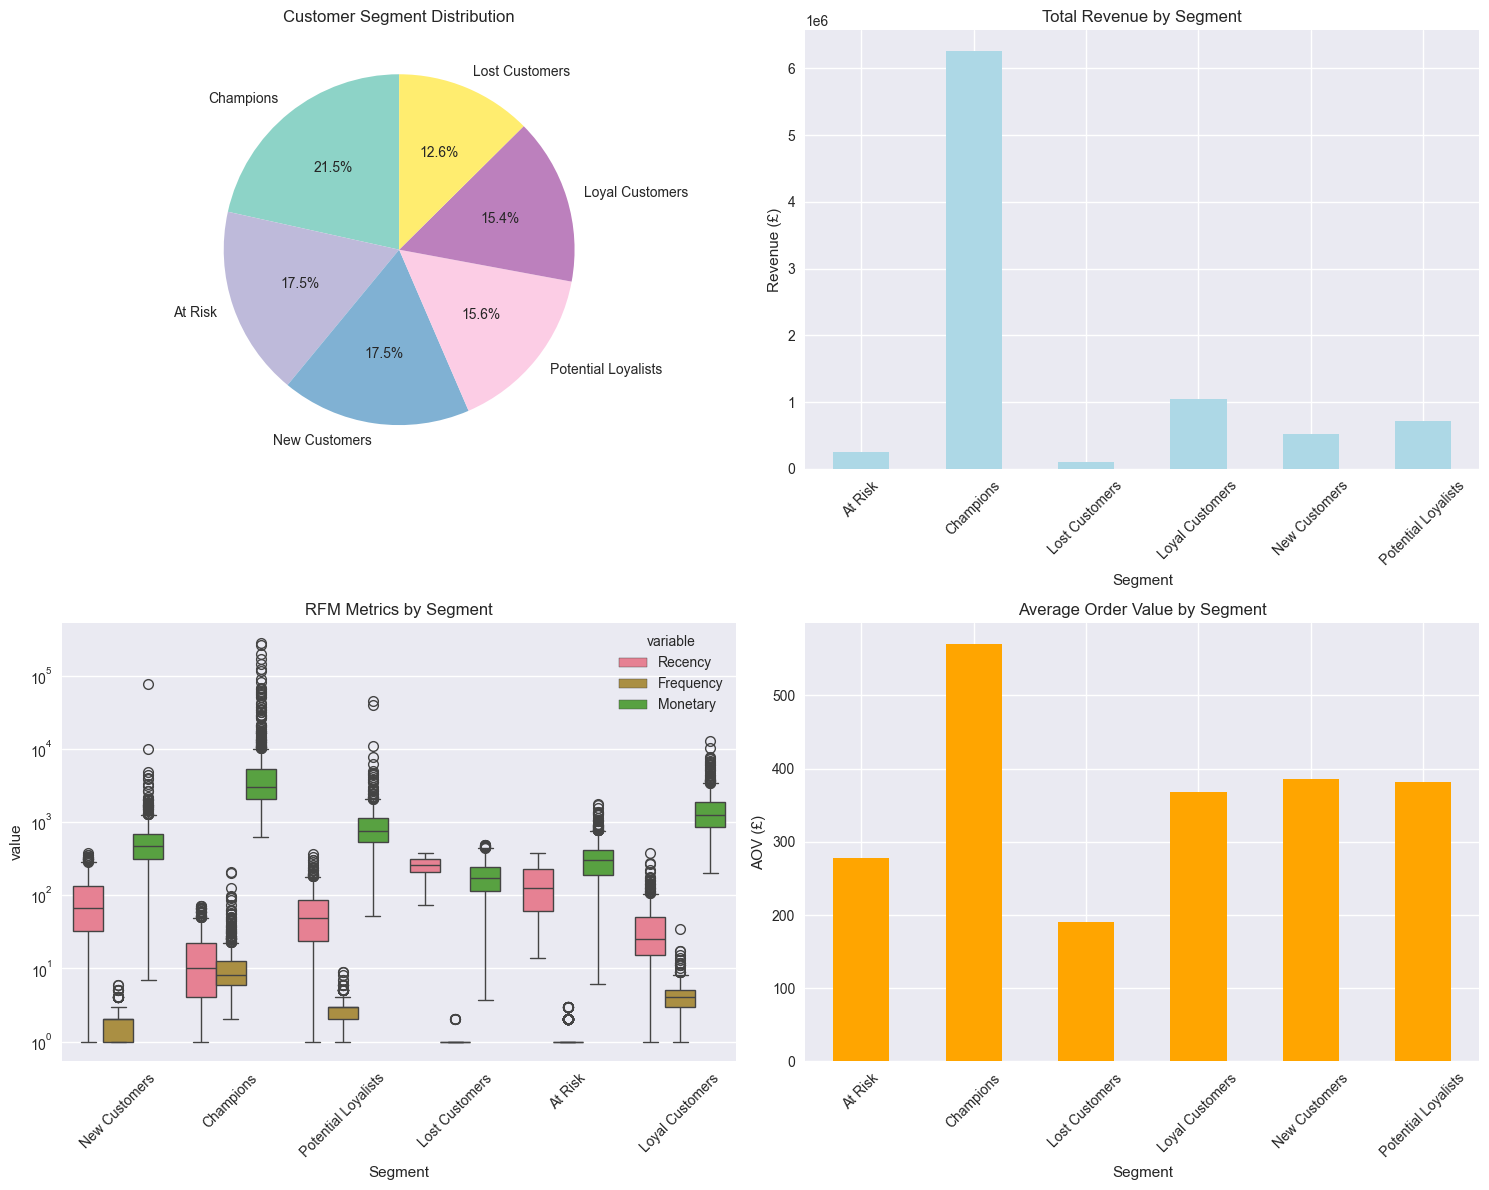

In [42]:
# Visualize customer segments
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Segment distribution
segment_counts = rfm['Segment'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(segment_counts)))
axes[0,0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', 
              colors=colors, startangle=90)
axes[0,0].set_title('Customer Segment Distribution')

# Revenue by segment
segment_analysis['Total_Revenue'].plot(kind='bar', ax=axes[0,1], color='lightblue')
axes[0,1].set_title('Total Revenue by Segment')
axes[0,1].set_ylabel('Revenue (£)')
axes[0,1].tick_params(axis='x', rotation=45)

# RFM distribution by segment
rfm_melt = rfm.melt(id_vars=['Segment'], value_vars=['Recency', 'Frequency', 'Monetary'])
sns.boxplot(data=rfm_melt, x='Segment', y='value', hue='variable', ax=axes[1,0])
axes[1,0].set_title('RFM Metrics by Segment')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_yscale('log')

# Average order value by segment
avg_order_value = segment_analysis['Avg_Monetary'] / segment_analysis['Avg_Frequency']
avg_order_value.plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].set_title('Average Order Value by Segment')
axes[1,1].set_ylabel('AOV (£)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


=== TOP 20 PRODUCTS BY REVENUE ===
                                              Total_Quantity  Total_Revenue  \
StockCode Description                                                         
23843     PAPER CRAFT , LITTLE BIRDIE                  80995      168469.60   
22423     REGENCY CAKESTAND 3 TIER                     12402      142592.95   
85123A    WHITE HANGING HEART T-LIGHT HOLDER           36725      100448.15   
85099B    JUMBO BAG RED RETROSPOT                      46181       85220.78   
23166     MEDIUM CERAMIC TOP STORAGE JAR               77916       81416.73   
POST      POSTAGE                                       3120       77803.96   
47566     PARTY BUNTING                                15291       68844.33   
84879     ASSORTED COLOUR BIRD ORNAMENT                35362       56580.34   
M         Manual                                        7173       53779.93   
23084     RABBIT NIGHT LIGHT                           27202       51346.20   
79321     CHILLI 

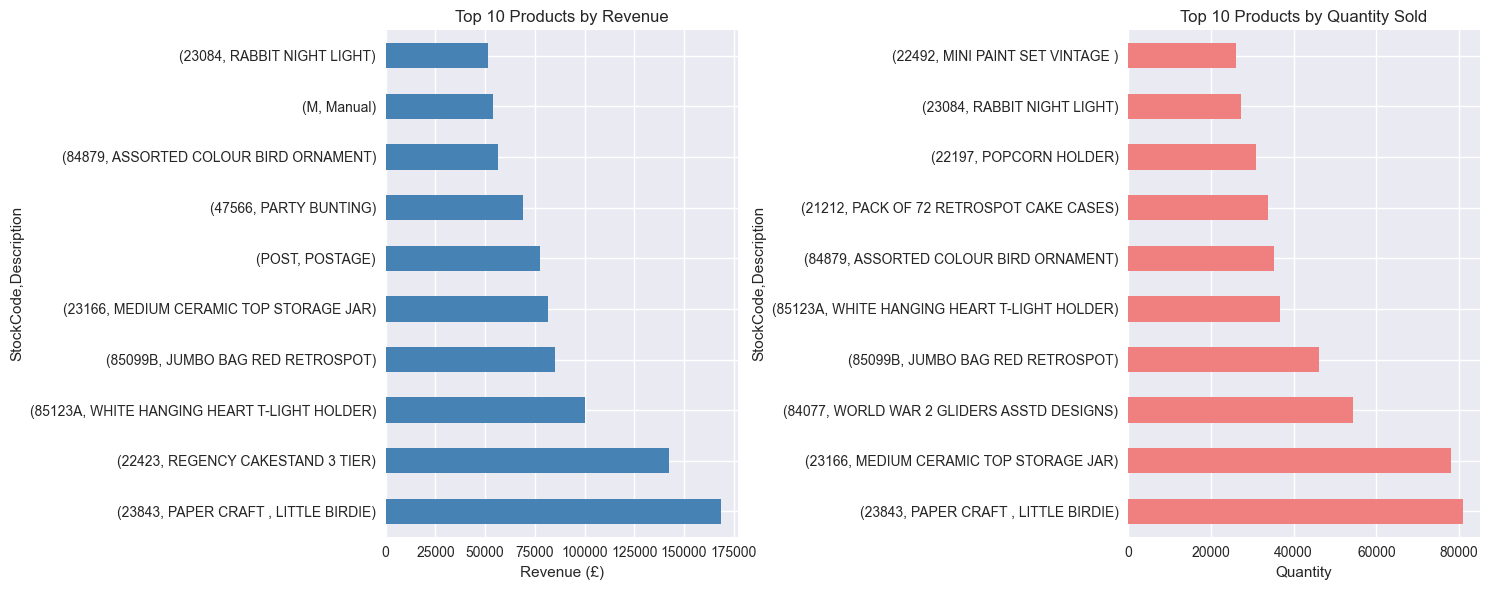

In [43]:
# Top products analysis
product_analysis = df_clean.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'CustomerID': 'nunique'
}).round(2)

product_analysis.columns = ['Total_Quantity', 'Total_Revenue', 'Unique_Customers']
product_analysis = product_analysis.sort_values('Total_Revenue', ascending=False)

print("=== TOP 20 PRODUCTS BY REVENUE ===")
top_products = product_analysis.head(20)
print(top_products)

# Visualize top products
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 by revenue
top_10_revenue = product_analysis.head(10)
ax1 = top_10_revenue['Total_Revenue'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Revenue (£)')

# Top 10 by quantity
top_10_quantity = product_analysis.sort_values('Total_Quantity', ascending=False).head(10)
ax2 = top_10_quantity['Total_Quantity'].plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Top 10 Products by Quantity Sold')
axes[1].set_xlabel('Quantity')

plt.tight_layout()
plt.show()


=== TOP 15 COUNTRIES BY REVENUE ===
                Total_Revenue  Unique_Customers  Total_Orders  \
Country                                                         
United Kingdom     7308391.55              3920         16646   
Netherlands         285446.34                 9            94   
EIRE                265545.90                 3           260   
Germany             228867.14                94           457   
France              209024.05                87           389   
Australia           138521.31                 9            57   
Spain                61577.11                30            90   
Switzerland          56443.95                21            51   
Belgium              41196.34                25            98   
Sweden               38378.33                 8            36   
Japan                37416.37                 8            19   
Norway               36165.44                10            36   
Portugal             33439.89                19       

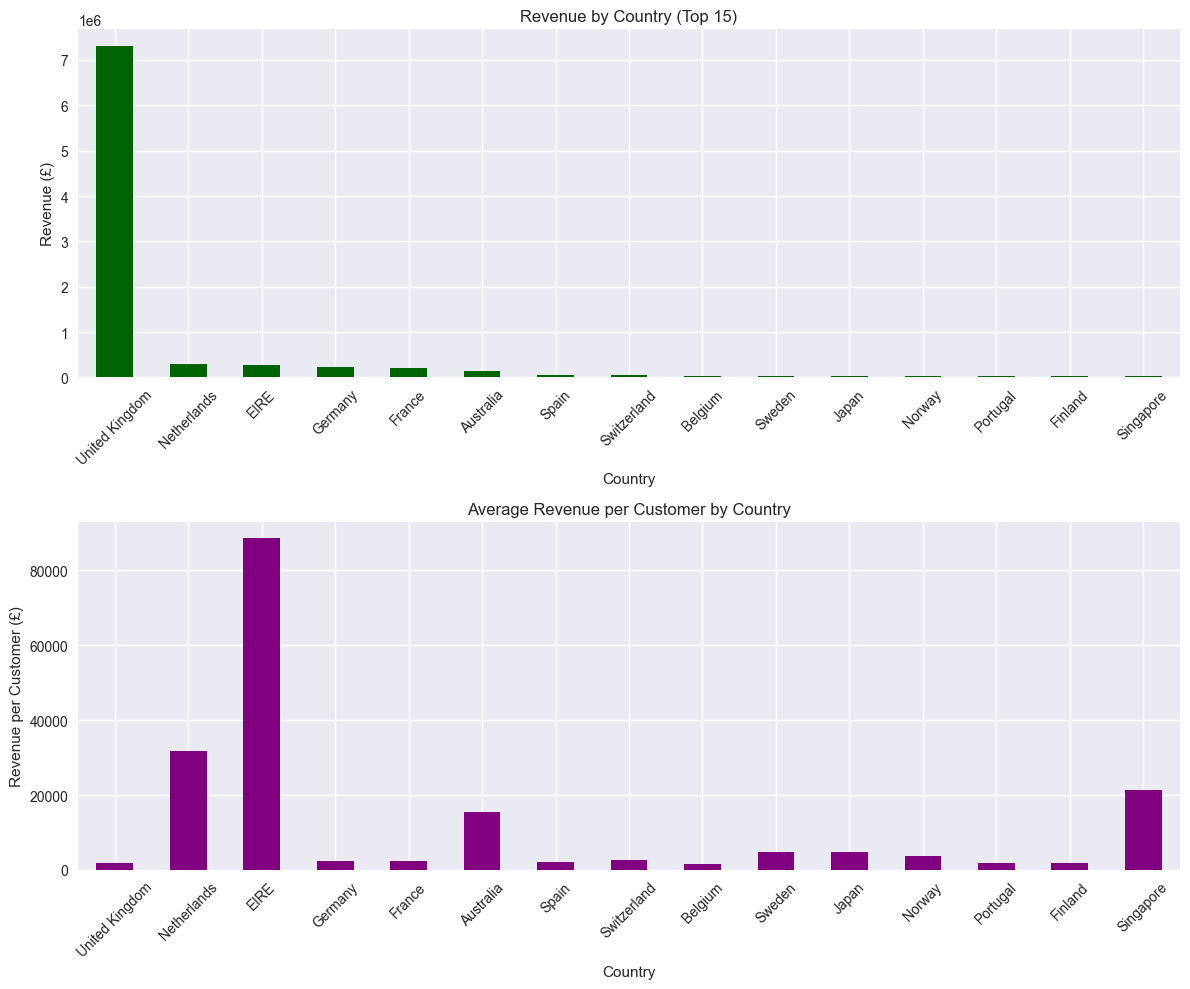

In [44]:
# Country analysis
country_analysis = df_clean.groupby('Country').agg({
    'TotalAmount': 'sum',
    'CustomerID': 'nunique',
    'InvoiceNo': 'nunique'
}).round(2)

country_analysis.columns = ['Total_Revenue', 'Unique_Customers', 'Total_Orders']
country_analysis['Avg_Revenue_Per_Customer'] = (country_analysis['Total_Revenue'] / country_analysis['Unique_Customers']).round(2)
country_analysis = country_analysis.sort_values('Total_Revenue', ascending=False)

print("=== TOP 15 COUNTRIES BY REVENUE ===")
print(country_analysis.head(15))

# Visualize geographic performance
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top countries by revenue
top_countries = country_analysis.head(15)
top_countries['Total_Revenue'].plot(kind='bar', ax=axes[0], color='darkgreen')
axes[0].set_title('Revenue by Country (Top 15)')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)

# Revenue per customer by country
top_countries['Avg_Revenue_Per_Customer'].plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Average Revenue per Customer by Country')
axes[1].set_ylabel('Revenue per Customer (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


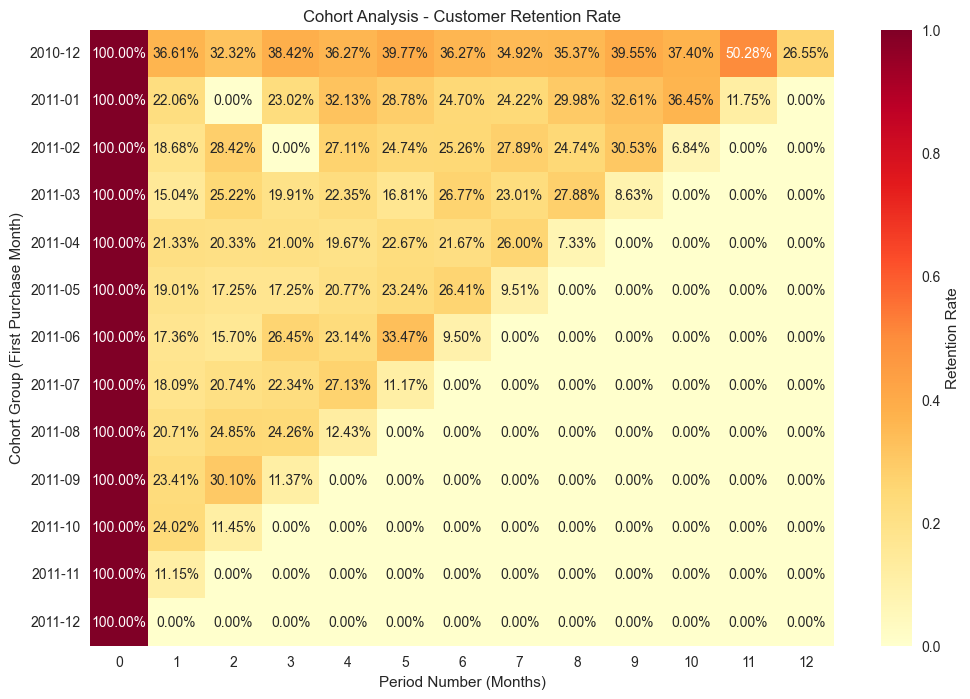

=== AVERAGE RETENTION RATES ===
Month 0: 100.00%
Month 1: 19.04%
Month 2: 17.42%
Month 3: 15.69%
Month 4: 17.00%
Month 5: 15.43%
Month 6: 13.12%
Month 7: 11.20%
Month 8: 9.64%
Month 9: 8.56%
Month 10: 6.21%
Month 11: 4.77%
Month 12: 2.04%

=== COHORT SUMMARY ===
Total cohorts analyzed: 13
Maximum retention period: 12 months
Average first-month retention: 19.04%


In [45]:
# Cohort analysis
def get_month(x):
    return x.strftime('%Y-%m')

# Get customer's first purchase date
df_clean['OrderPeriod'] = df_clean['InvoiceDate'].apply(get_month)
df_clean['CohortGroup'] = df_clean.groupby('CustomerID')['InvoiceDate'].transform('min').apply(get_month)

# Create cohort table - Fixed to handle duplicates
df_cohort = df_clean.groupby(['CohortGroup', 'OrderPeriod'])['CustomerID'].nunique().reset_index()
cohort_sizes = df_clean.groupby('CohortGroup')['CustomerID'].nunique().reset_index()
cohort_sizes.columns = ['CohortGroup', 'CohortSize']

df_cohort = df_cohort.merge(cohort_sizes, on='CohortGroup')
df_cohort['PeriodNumber'] = (df_cohort['OrderPeriod'].apply(lambda x: datetime.strptime(x, '%Y-%m')) - 
                            df_cohort['CohortGroup'].apply(lambda x: datetime.strptime(x, '%Y-%m'))).dt.days // 30

# Calculate retention rate
df_cohort['RetentionRate'] = df_cohort['CustomerID'] / df_cohort['CohortSize']

# Remove any duplicate combinations before pivoting
df_cohort = df_cohort.drop_duplicates(subset=['CohortGroup', 'PeriodNumber'])

# Create cohort matrix
cohort_matrix = df_cohort.pivot(index='CohortGroup', columns='PeriodNumber', values='RetentionRate')

# Handle missing values in the matrix
cohort_matrix = cohort_matrix.fillna(0)

# Visualize cohort analysis
plt.figure(figsize=(12, 8))
sns.heatmap(cohort_matrix, annot=True, fmt='.2%', cmap='YlOrRd', cbar_kws={'label': 'Retention Rate'})
plt.title('Cohort Analysis - Customer Retention Rate')
plt.xlabel('Period Number (Months)')
plt.ylabel('Cohort Group (First Purchase Month)')
plt.show()

print("=== AVERAGE RETENTION RATES ===")
avg_retention = cohort_matrix.mean().round(4)
for period, rate in avg_retention.items():
    if pd.notna(rate):  # Only show periods with data
        print(f"Month {period}: {rate:.2%}")
        
print(f"\n=== COHORT SUMMARY ===")
print(f"Total cohorts analyzed: {len(cohort_matrix)}")
print(f"Maximum retention period: {cohort_matrix.columns.max()} months")
print(f"Average first-month retention: {cohort_matrix[1].mean():.2%}" if 1 in cohort_matrix.columns else "No month-1 data")


In [46]:
# Summary insights with error handling for missing segments
print("="*60)
print("             KEY BUSINESS INSIGHTS")
print("="*60)

print("\n🎯 CUSTOMER SEGMENTATION INSIGHTS:")
segments = ['Champions', 'At Risk', 'Lost Customers']
for segment in segments:
    if segment in segment_analysis.index:
        count = segment_analysis.loc[segment, 'Customer_Count']
        revenue_pct = segment_analysis.loc[segment, 'Revenue_Percentage']
        if segment == 'Champions':
            print(f"• {segment}: {count} customers ({revenue_pct:.1f}% of revenue)")
        else:
            print(f"• {segment}: {count} customers need {'retention' if segment == 'At Risk' else 're-engagement'} efforts")
    else:
        print(f"• {segment}: No customers in this segment")

print("\n📈 SALES PERFORMANCE:")
best_month = monthly_sales.idxmax()
best_day = daily_sales.idxmax()
peak_hour = hourly_sales.idxmax()
print(f"• Peak sales month: {best_month}")
print(f"• Best performing day: {best_day}")
print(f"• Peak sales hour: {peak_hour}:00")

print("\n🌍 GEOGRAPHIC INSIGHTS:")
uk_revenue_pct = (country_analysis.loc['United Kingdom', 'Total_Revenue'] / country_analysis['Total_Revenue'].sum()) * 100
print(f"• UK dominates with {uk_revenue_pct:.1f}% of total revenue")
print(f"• International markets represent {100-uk_revenue_pct:.1f}% growth opportunity")

print("\n🛒 PRODUCT INSIGHTS:")
top_product_revenue = product_analysis.iloc[0]['Total_Revenue']
total_product_revenue = product_analysis['Total_Revenue'].sum()
top_product_pct = (top_product_revenue / total_product_revenue) * 100
print(f"• Top product generates {top_product_pct:.1f}% of revenue")
print(f"• Product diversification shows healthy distribution")

print("\n🔄 RETENTION INSIGHTS:")
if len(avg_retention) > 1:
    month_1_retention = avg_retention.iloc[1] if len(avg_retention) > 1 else 0
    print(f"• Month 1 retention rate: {month_1_retention:.1%}")
    if len(avg_retention) > 6:
        month_6_retention = avg_retention.iloc[6]
        print(f"• Month 6 retention rate: {month_6_retention:.1%}")

print("\n" + "="*60)
print("           STRATEGIC RECOMMENDATIONS")
print("="*60)

print("\n💎 CHAMPIONS STRATEGY:")
print("• Implement VIP program with exclusive benefits")
print("• Use as brand ambassadors for referral programs")
print("• Offer early access to new products")

print("\n⚠️ AT-RISK CUSTOMERS:")
print("• Launch targeted email campaigns with discounts")
print("• Implement win-back campaigns")
print("• Survey to understand satisfaction issues")

print("\n🌟 POTENTIAL LOYALISTS:")
print("• Increase engagement through personalized recommendations")
print("• Offer loyalty program enrollment")
print("• Provide excellent customer service to build trust")

print("\n🌍 INTERNATIONAL EXPANSION:")
print("• Focus marketing efforts on high-performing international markets")
print("• Localize product offerings and pricing")
print("• Optimize shipping and logistics for key regions")

print("\n📊 OPERATIONAL IMPROVEMENTS:")
print(f"• Schedule marketing campaigns for {best_day}s")
print(f"• Ensure adequate staffing during peak hour ({peak_hour}:00)")
print("• Prepare inventory for seasonal peaks")


             KEY BUSINESS INSIGHTS

🎯 CUSTOMER SEGMENTATION INSIGHTS:
• Champions: 934 customers (70.2% of revenue)
• At Risk: 759 customers need retention efforts
• Lost Customers: 545 customers need re-engagement efforts

📈 SALES PERFORMANCE:
• Peak sales month: 2011-11
• Best performing day: Thursday
• Peak sales hour: 12:00

🌍 GEOGRAPHIC INSIGHTS:
• UK dominates with 82.0% of total revenue
• International markets represent 18.0% growth opportunity

🛒 PRODUCT INSIGHTS:
• Top product generates 1.9% of revenue
• Product diversification shows healthy distribution

🔄 RETENTION INSIGHTS:
• Month 1 retention rate: 19.0%
• Month 6 retention rate: 13.1%

           STRATEGIC RECOMMENDATIONS

💎 CHAMPIONS STRATEGY:
• Implement VIP program with exclusive benefits
• Use as brand ambassadors for referral programs
• Offer early access to new products

⚠️ AT-RISK CUSTOMERS:
• Launch targeted email campaigns with discounts
• Implement win-back campaigns
• Survey to understand satisfaction issues

🌟